# Observable Signature searching
- this notebook looks for differences between whole cube projectionplots and the targetted bubble region projectionplot.

Begin by extracting a midplane square that contains the bubble

In [157]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches 
import yt
import numpy as np
import os
from astropy import units as u
import cv2 as cv
from utils import *


# elephant
hdf5_root = "/srv/data/stratbox_simulations/stratbox_particle_runs/bx5/smd132/sn34/pe300/4pc_resume/4pc"
pplot_root = "/home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots"
masks_root = "/home/joy0921/Desktop/Dataset/img_pix256/masks/SB-small/SN180-179-122"

time_Myr = 191.7

ds = yt.load(os.path.join(hdf5_root, 'sn34_smd132_bx5_pe300_hdf5_plt_cnt_0{}'.format(time_Myr2timestamp(time_Myr))))

center = [0, 0, 0] * yt.units.pc
arb_center = ds.arr(center, 'code_length')
xlim, ylim, zlim = 256, 256, 256
left_edge = arb_center + ds.quan(-500, 'pc')        
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(xlim,ylim,zlim))

print(obj["flash", "dens"].shape)

yt : [INFO     ] 2024-09-16 17:52:34,056 Particle file found: sn34_smd132_bx5_pe300_hdf5_part_0207
yt : [INFO     ] 2024-09-16 17:52:34,131 Parameters: current_time              = 6049650437981840.0
yt : [INFO     ] 2024-09-16 17:52:34,132 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-09-16 17:52:34,133 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-09-16 17:52:34,134 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [INFO     ] 2024-09-16 17:52:34,134 Parameters: cosmological_simulation   = 0


(256, 256, 256)


# Projection plot movies
- then projection plot both the cube

In [158]:
prj = yt.ProjectionPlot(ds, 'z', 'dens', center = [0, 0, 0] * yt.units.pc)
# prj.annotate_sphere([439, -68], radius=(10, "pc"), coord_system="plot", text="")
# prj.annotate_text([439 + 10, -68], "explosion", coord_system="plot")

prj.annotate_timestamp()
prj.annotate_scale()

filename = f"{time_Myr}_cube"

prj.save(os.path.join(pplot_root, f'{filename}.png'))

yt : [INFO     ] 2024-09-16 17:52:45,418 Projection completed
yt : [INFO     ] 2024-09-16 17:52:45,423 xlim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-16 17:52:45,423 ylim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-16 17:52:45,426 xlim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-16 17:52:45,427 ylim = -1542838790000000106496.000000 1542838790000000106496.000000
yt : [INFO     ] 2024-09-16 17:52:45,430 Making a fixed resolution buffer of (('flash', 'dens')) 800 by 800
yt : [INFO     ] 2024-09-16 17:52:46,525 Saving plot /home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/191.7_cube.png


['/home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/191.7_cube.png']

In [150]:
def get_velz_dens(obj, x_range, y_range, z_range):
    # read a 3D grid of velz and density array
    velz = obj["flash", "velz"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value        
    dens = obj["flash", "dens"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('g/cm**3').value        
    temp = obj["flash", "temp"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('K').value 

    print(f"obj.shape: {obj['flash', 'velz'].shape}")
    print("x, y, z ranges: ", x_range, y_range, z_range)
    print(f"velz.shape: {velz.shape}\tdens.shape: {dens.shape}\n\n")      
     

    dz = obj['flash', 'dz'][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('cm').value
    mp = yt.physical_constants.mp.value # proton mass

    # calculate the density as column density
    coldens = dens * dz / (1.4 * mp)

    return velz, coldens, temp

obj.shape: (256, 256, 256)
x, y, z ranges:  (0, 256) (0, 256) (0, 256)
velz.shape: (256, 256, 256)	dens.shape: (256, 256, 256)




yt : [INFO     ] 2024-09-16 18:02:40,708 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-09-16 18:02:40,709 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2024-09-16 18:02:40,710 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-09-16 18:02:40,711 Parameters: domain_right_edge         = [256. 256. 256.]
yt : [INFO     ] 2024-09-16 18:02:40,712 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-09-16 18:02:42,668 Projection completed
yt : [INFO     ] 2024-09-16 18:02:42,674 xlim = 0.000000 256.000000
yt : [INFO     ] 2024-09-16 18:02:42,675 ylim = 0.000000 256.000000
yt : [INFO     ] 2024-09-16 18:02:42,679 xlim = 0.000000 256.000000
yt : [INFO     ] 2024-09-16 18:02:42,680 ylim = 0.000000 256.000000
yt : [INFO     ] 2024-09-16 18:02:42,682 Making a fixed resolution buffer of (('stream', 'dens')) 800 by 800



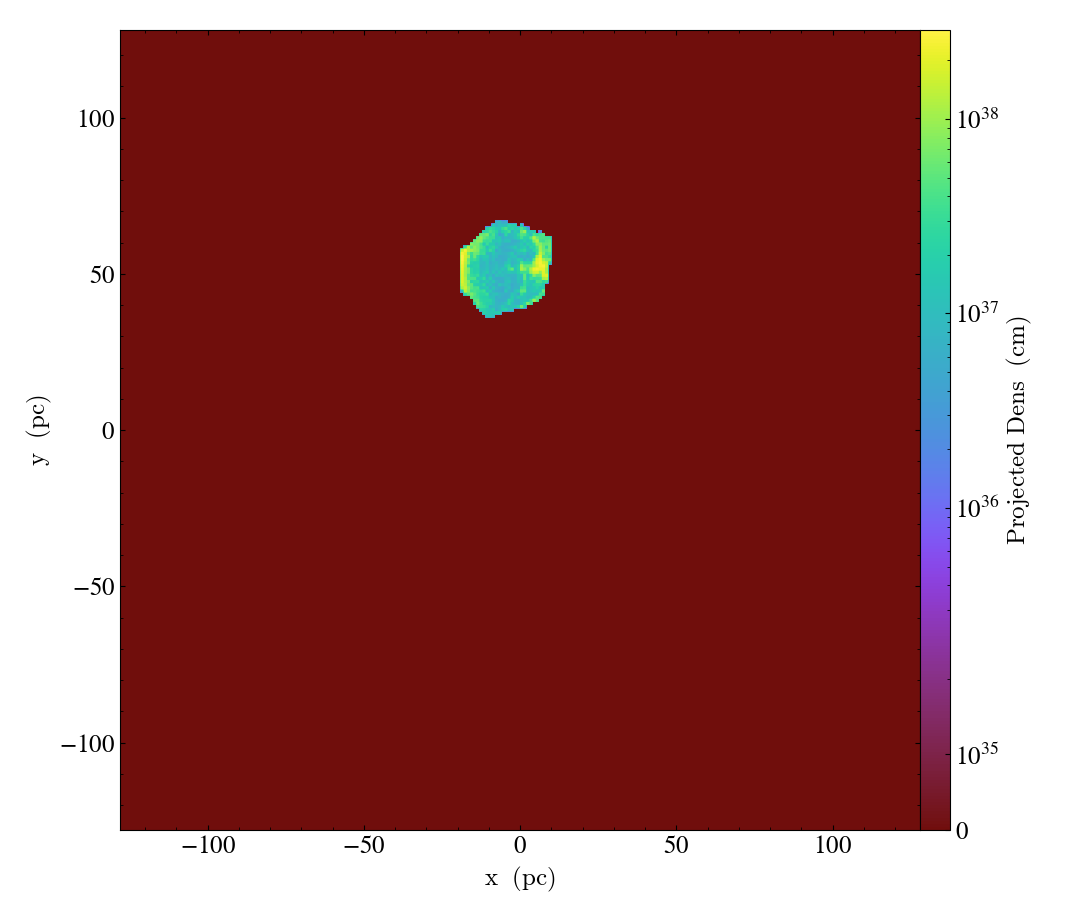

yt : [INFO     ] 2024-09-16 18:02:43,429 Saving plot /home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/191.7_target.png


['/home/joy0921/Desktop/Dataset/img_pix256/ProjectionPlots/191.7_target.png']

In [169]:
# Load the density array 

_, dens_cube, _ = get_velz_dens(obj, (0, 256), (0, 256), (0, 256))
density_array = obj['flash', 'dens']


# Path to masks directory
mask_dir = os.path.join(masks_root, str(time_Myr2timestamp(time_Myr)))
density_target = np.zeros((256, 256, 256))

# Iterate through all mask files (0.png to 255.png)
for z in range(256):
    mask_path = os.path.join(mask_dir, f"{z}.png")

    
    # Load the mask image and convert to a binary mask (1 for the region of interest, 0 otherwise)
    mask_img = cv.imread(mask_path, cv.IMREAD_GRAYSCALE)  #.convert('L')
    mask = mask_img / 255  # Normalize to range [0, 1]

    
    # Apply the mask to the corresponding z-slice of the density array
    density_target[z] = np.where(mask, dens_cube[:, :, z], 0)       # np.nan

# Create a yt dataset from the modified density array
data = {'dens': (density_target)}
bbox = np.array([[0, 256], [0, 256], [0, 256]])

ds_target = yt.load_uniform_grid(data, density_target.shape, bbox=bbox, length_unit='pc', nprocs=12)


# Generate the projection plot
prj_target = yt.ProjectionPlot(ds_target, 'z', 'dens', width=256 * yt.units.pc, center=[128, 128, 128] * yt.units.pc)
prj_target.show()

# prj.annotate_timestamp()
# prj.annotate_scale()

filename = f"{time_Myr}_target"

prj_target.save(os.path.join(pplot_root, f'{filename}.png'))


/tmp/ipykernel_339760/1030420203.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(density_target[122]) )


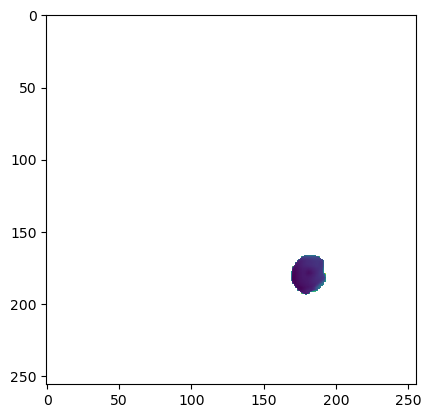

In [167]:
plt.imshow(np.log10(density_target[122]) )


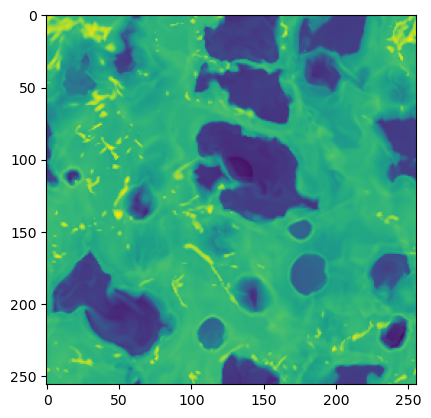

In [164]:
plt.imshow(np.log10(dens_cube[:, :, 122]) ) 

yt : [INFO     ] 2024-09-16 17:13:11,806 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-09-16 17:13:11,808 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2024-09-16 17:13:11,809 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-09-16 17:13:11,809 Parameters: domain_right_edge         = [128. 128. 128.]
yt : [INFO     ] 2024-09-16 17:13:11,810 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-09-16 17:13:12,125 Projection completed
yt : [INFO     ] 2024-09-16 17:13:12,126 xlim = 0.000000 128.000000
yt : [INFO     ] 2024-09-16 17:13:12,127 ylim = 0.000000 128.000000
yt : [INFO     ] 2024-09-16 17:13:12,130 xlim = 0.000000 128.000000
yt : [INFO     ] 2024-09-16 17:13:12,130 ylim = 0.000000 128.000000
yt : [INFO     ] 2024-09-16 17:13:12,133 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



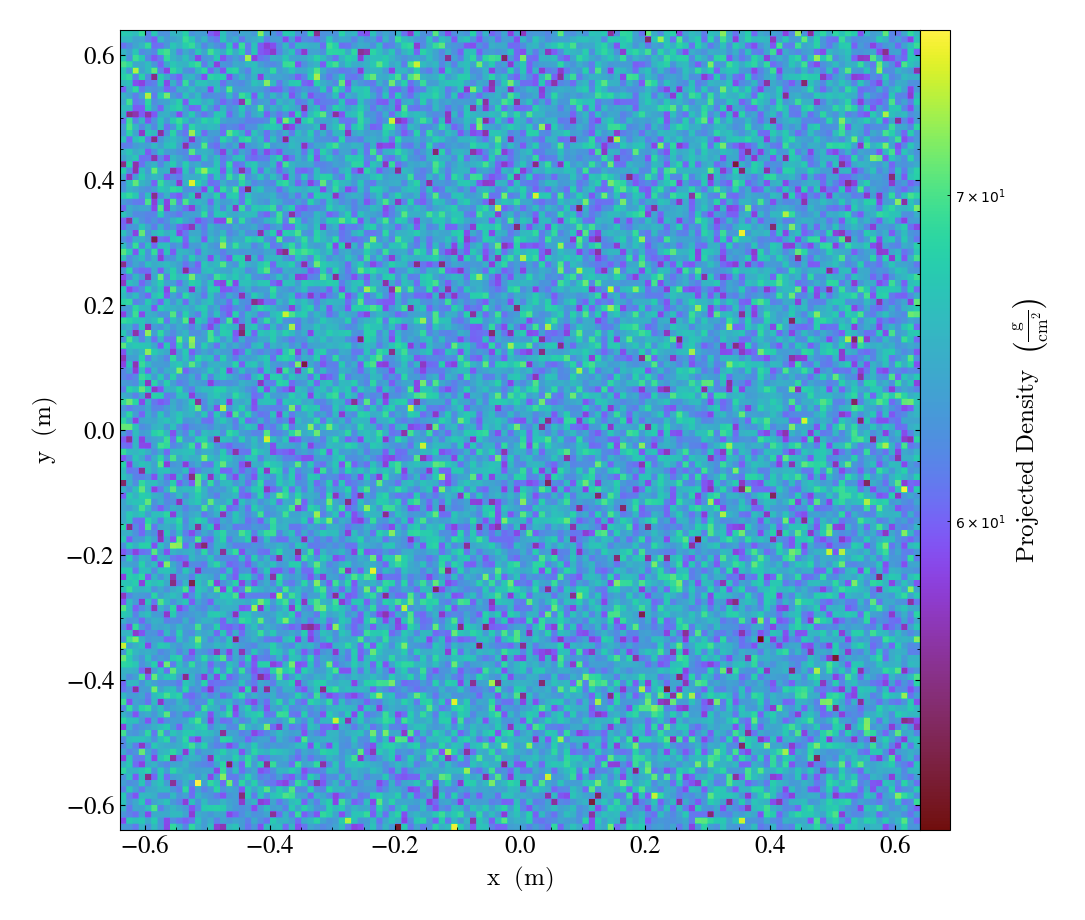

In [122]:
np.random.seed(int(0x4D3D3D3))

bbox = np.array([[0, 128], [0, 128], [0, 128]])

arr = np.random.random((128, 128, 128))

data = dict(density=arr)

ds_ex = yt.load_uniform_grid(data, arr.shape, length_unit="cm", bbox=bbox, nprocs=12)

dd = ds_ex.all_data()

prj_target = yt.ProjectionPlot(ds_ex, 'z', 'density')     # center=[0, 0, 0] * yt.units.pc
prj_target.show()
